In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [9]:


from google.colab import files
uploaded=files.upload()
print(uploaded)

Saving Titanic-Dataset.csv to Titanic-Dataset.csv
{'Titanic-Dataset.csv': b'PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked\r\n1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,,S\r\n2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C\r\n3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,,S\r\n4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S\r\n5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,,S\r\n6,0,3,"Moran, Mr. James",male,,0,0,330877,8.4583,,Q\r\n7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S\r\n8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,,S\r\n9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,,S\r\n10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,,C\r\n11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4,1,1,PP 9549,16.7,G6,S\r\n12,1,1,"Bo

In [10]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
df.shape

(891, 12)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [15]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [17]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

,0
Cabin,77.104377
Age,19.865320
Embarked,0.224467
PassengerId,0.000000
Name,0.000000
Pclass,0.000000
Survived,0.000000
Sex,0.000000
Parch,0.000000
SibSp,0.000000


In [18]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [19]:
df.drop("Cabin", axis=1, inplace=True)

In [21]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [22]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [23]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [24]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'embarked'],
      dtype='object')

In [25]:
text_columns = ["name", "sex", "ticket", "embarked"]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

In [26]:
print("Sex:", df["sex"].unique())
print("Embarked:", df["embarked"].unique())
print("Passenger Class:", df["pclass"].unique())

Sex: ['male' 'female']
Embarked: ['S' 'C' 'Q']
Passenger Class: [3 1 2]


In [45]:
df.rename(columns={"sex": "is_female"}, inplace=True)

# Encode values
df["is_female"] = df["is_female"].map({
    "male": 0,
    "female": 1
})

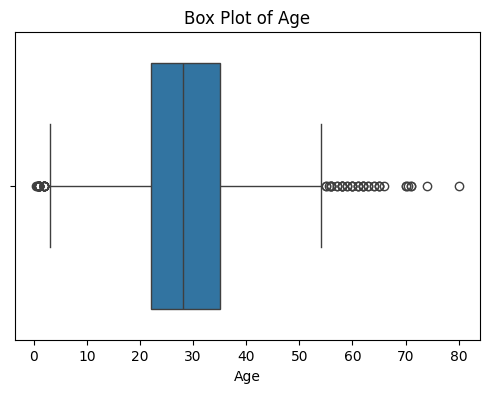

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["age"])

plt.title("Box Plot of Age")
plt.xlabel("Age")

plt.show()

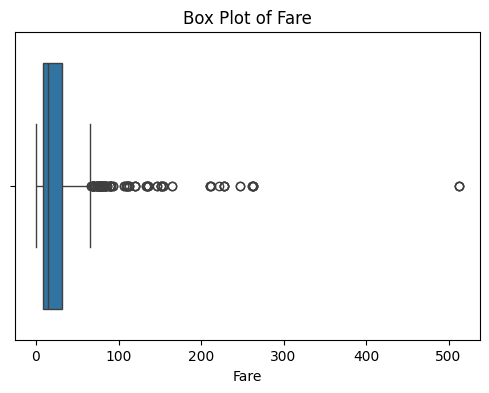

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["fare"])

plt.title("Box Plot of Fare")
plt.xlabel("Fare")

plt.show()

In [29]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[(df["fare"] >= lower_limit) & (df["fare"] <= upper_limit)]

In [30]:
print("Dataset Shape After Removing Outliers:", df.shape)

Dataset Shape After Removing Outliers: (775, 11)


In [31]:
df.to_csv("Cleaned_Titanic_Dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


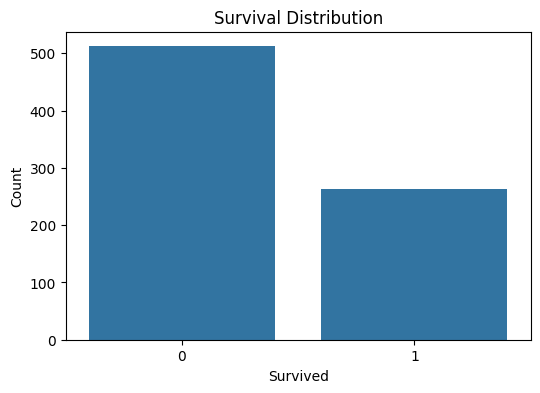

In [32]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="survived")

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

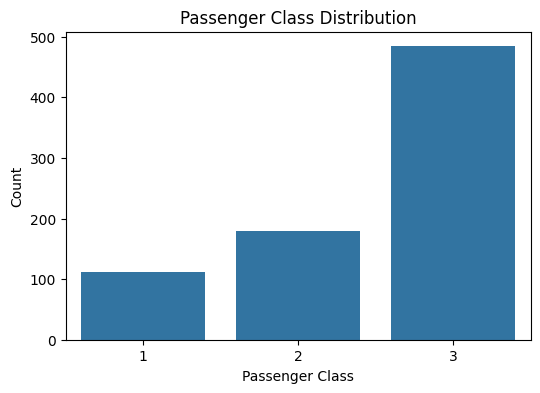

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="pclass")

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

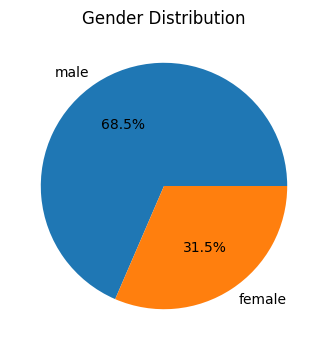

In [34]:
plt.figure(figsize=(6,4))

df["sex"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Gender Distribution")

plt.show()

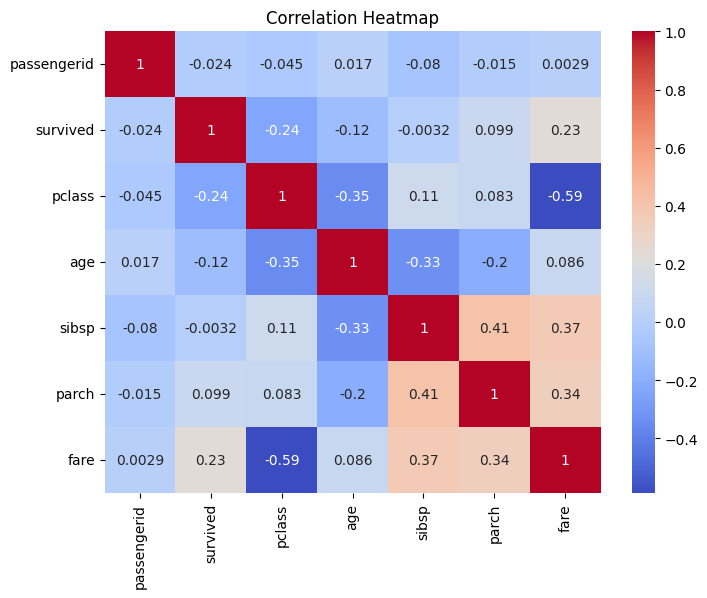

In [36]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [38]:
print("Minimum Age:", df["age"].min())
print("Maximum Age:", df["age"].max())

print("Minimum Fare:", df["fare"].min())
print("Maximum Fare:", df["fare"].max())

Minimum Age: 0.42
Maximum Age: 80.0
Minimum Fare: 0.0
Maximum Fare: 65.0


In [39]:
print(df["sex"].value_counts())

print(df["embarked"].value_counts())

sex
male      531
female    244
Name: count, dtype: int64
embarked
S    584
C    116
Q     75
Name: count, dtype: int64


In [40]:
df["family_size"] = df["sibsp"] + df["parch"] + 1

In [41]:
df["is_alone"] = (df["family_size"] == 1).astype(int)

In [43]:
print(df["age"].skew())

print(df["fare"].skew())

0.5182338915748297
1.4306715336945985


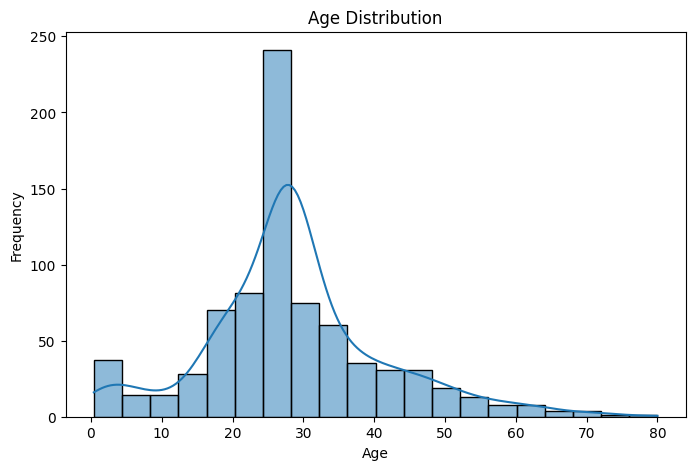

In [44]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [48]:
df = pd.get_dummies(df, columns=["embarked"], prefix="embarked", dtype=int)

In [49]:
df.head()

,passengerid,survived,pclass,name,is_female,age,sibsp,parch,ticket,fare,family_size,is_alone,embarked_C,embarked_Q,embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,2,0,0,0,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,1,1,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,2,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,1,1,0,0,1
5,6,0,3,"Moran, Mr. James",0,28.0,0,0,330877,8.4583,1,1,0,1,0
